### Importing Libraries

In [50]:
import pandas as pd
import numpy as np
import re 

# Exploratory Data Analysis & Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Selection & Preprocessing 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Class imbalance 
#from imbalanced-learn.over_sampling import SMOTE


# Model 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
#import lightgbm as lgb

# Model Evaluation 
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve)

# Explainability
#import SHAP

print("Import successful")

Import successful


### Loading the data

In [51]:
df_transaction = pd.read_csv(r"C:\Users\leest\OneDrive\Data Projects\Amdari Projects\Digital_Transfer_Fraud_Detection_System\FinLora_Customer_Transaction_Dataset.csv")

# Make a copy for reference to original data
df_transaction_copy = df_transaction.copy() 

### Data Dictionary — FinLora Transaction Dataset

| # | Column | Description |
|---|--------|--------------|
| 0 | `transaction_id` | Unique identifier for each transaction. |
| 1 | `customer_id` | Unique identifier for the customer who initiated the transaction. |
| 2 | `timestamp` | Date and time the transaction occurred (UTC). |
| 3 | `home_country` | Customer's registered home/residence country. |
| 4 | `source_currency` | Currency the transaction was sent in. |
| 5 | `dest_currency` | Currency the transaction was received in. |
| 6 | `channel` | Payment channel used to initiate the transaction (e.g., ATM, web, mobile). |
| 7 | `amount_src` | Transaction amount in the source currency. |
| 8 | `amount_usd` | Source transaction amount converted to USD, for standardised comparison across currencies. |
| 9 | `fee` | Fee charged on the transaction. |
| 10 | `exchange_rate_src_to_dest` | Exchange rate applied between source and destination currency at time of transaction. |
| 11 | `device_id` | Identifier for the device used to initiate the transaction. |
| 12 | `new_device` | Whether the transaction was initiated from a device not previously associated with the customer (True/False). |
| 13 | `ip_address` | IP address the transaction originated from. |
| 14 | `ip_country` | Country inferred from the transaction's IP address. |
| 15 | `location_mismatch` | Whether the customer's declared/home location differs from the IP-inferred location (True/False) — a common fraud signal. |
| 16 | `ip_risk_score` | Risk score associated with the originating IP address (e.g., linked to VPNs, proxies, known bad actors). |
| 17 | `kyc_tier` | Customer's Know Your Customer verification level/tier (Enhanced, Low, Standard). |
| 18 | `account_age_days` | Number of days since the customer's account was created. |
| 19 | `device_trust_score` | Trust/reputation score associated with the device used to initiate transaction. |
| 20 | `chargeback_history_count` | Number of prior chargebacks associated with the customer — historical fraud/dispute signal. |
| 21 | `risk_score_internal` | FinLora's existing internal risk score (likely output of the current rule-based system) for the transaction. |
| 22 | `txn_velocity_1h` | Number of transactions made by the customer in the past 1 hour. |
| 23 | `txn_velocity_24h` | Number of transactions made by the customer in the past 24 hours. |
| 24 | `corridor_risk` | Risk score associated with the specific source-to-destination country/currency "corridor" (some corridors are higher-risk for fraud/money laundering). |
| 25 | `is_fraud` | **Target variable.** Indicates whether the transaction was confirmed fraudulent (1) or legitimate (0). |

### Initial Data Quality Checks 

In [52]:
# Checking the first 5 transactions in the data
df_transaction.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [53]:
# Checking for number of records and features in the given data 
print(f"The data has {df_transaction.shape[0]} financial transactions records and {df_transaction.shape[1]} features ")

The data has 11400 financial transactions records and 26 features 


In [54]:
# Checking for duplicate transaction_id
print(f"There are {df_transaction.duplicated(subset='transaction_id').sum()} duplicate records in the data")

# print(f"There are {df_transaction.duplicated().sum()} duplicate transaction_ids in the data")

There are 200 duplicate records in the data


In [55]:
# Check for data types and missing values 
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [56]:
# Checking for null values in features 

df_transaction.isnull().sum()
#(df_transaction.isnull().mean()*100).round(2)

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

The missing values across the dataset are minimal and not a cause for concern — generally under 3% per column. These will be addressed in the data cleaning steps that follow.

In [57]:
# Converting timestamp to datetime data type 
df_transaction["timestamp"] = pd.to_datetime(df_transaction["timestamp"], errors="coerce")

# Converting amount_src to numeric data 
df_transaction["amount_src"] = pd.to_numeric(df_transaction["amount_src"], errors= "coerce")

In [58]:
# Sanity check - Object data types check 
object_cols = df_transaction.select_dtypes(include='object').columns

for col in object_cols:
    unique_types = df_transaction[col].apply(lambda x: type(x).__name__).value_counts()
    print(f"Column: {col}")
    print(unique_types)
    print("-" * 40)

Column: transaction_id
transaction_id
str    11400
Name: count, dtype: int64
----------------------------------------
Column: customer_id
customer_id
str    11400
Name: count, dtype: int64
----------------------------------------
Column: home_country
home_country
str    11400
Name: count, dtype: int64
----------------------------------------
Column: source_currency
source_currency
str    11400
Name: count, dtype: int64
----------------------------------------
Column: dest_currency
dest_currency
str    11400
Name: count, dtype: int64
----------------------------------------
Column: channel
channel
str    11400
Name: count, dtype: int64
----------------------------------------
Column: device_id
device_id
str    11400
Name: count, dtype: int64
----------------------------------------
Column: ip_address
ip_address
str      11095
float      305
Name: count, dtype: int64
----------------------------------------
Column: ip_country
ip_country
str      11099
float      301
Name: count, dtype: i

In [59]:
# Sanity check 
df_transaction.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     61
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     4
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

The `timestamp` and `amount_src` columns were converted to datetime and numeric (float) data types respectively. Using `errors='coerce'` allows the conversion to proceed without breaking, by converting any unparseable or invalid values to nulls rather than raising an error. As a result, the number of missing values specifically for timestamp increased from 29 to 61, as confirmed in the sanity checks above.

#### Handling data inconsistencies in categorical columns 

In [62]:
# Checking for unique values in categorical values

cat_cols = ["home_country", "source_currency", "dest_currency", "channel", "ip_country", "kyc_tier"]

for col in cat_cols:
    print(f"\n{col}")
    print(df_transaction[col].unique())
    print("-" * 40)


home_country
['US' 'CA' 'UK' 'unknown']
----------------------------------------

source_currency
['USD' 'CAD' 'GBP']
----------------------------------------

dest_currency
['CAD' 'MXN' 'CNY' 'EUR' 'INR' 'GBP' 'PHP' 'NGN' 'USD']
----------------------------------------

channel
['ATM' 'web' 'mobile' 'WEB' 'MOBILE' 'mobille' 'unknown' 'weeb' 'ATm']
----------------------------------------

ip_country
['US' 'CA' nan 'UK' ' US  ' 'NAN' 'unknown' ' CA  ' ' UK  ' ' nan  ']
----------------------------------------

kyc_tier
['standard' 'enhanced' 'low' ' standard  ' nan 'standrd' ' enhanced  '
 'STANDARD' 'NAN' 'unknown' 'enhancd' ' low  ' 'ENHANCED' 'LOW' ' nan  ']
----------------------------------------


In [ ]:
# Standardising categorical text columns 
# Step 1 - Removing whitespaces

for cols in cat_cols:
    df_transaction[cols] = (df_transaction[cols].str.strip().str.replace(r'\s+', ' ', regex=True))

In [65]:
# Changingig specific columns to lowercase 

cat_cols_lower = ["channel", "kyc_tier"]

for cols in cat_cols_lower:
    df_transaction[cols] = (df_transaction[cols].str.lower())

In [69]:
# Step 2 - Correcting spellings

cat_cols_dict = {"mobille": "mobile", "weeb": "web", "standrd": "standard", "enhancd": "enhanced"}

for col in cat_cols_lower:
    df_transaction[col] = df_transaction[col].replace(cat_cols_dict)

In [71]:
# Step 3 - Replacing placeholder values with numpy null

place_holder_misisng = ["unknown", "nan", "NAN"]

for cols in cat_cols:
    df_transaction[cols] = df_transaction[cols].replace(place_holder_misisng,np.nan)

In [ ]:
# Sanity check
for col in cat_cols:
    print(f"\n{col}")
    print(df_transaction[col].unique())
    print("-" * 40)


home_country
['US' 'CA' 'UK' nan]
----------------------------------------

source_currency
['USD' 'CAD' 'GBP']
----------------------------------------

dest_currency
['CAD' 'MXN' 'CNY' 'EUR' 'INR' 'GBP' 'PHP' 'NGN' 'USD']
----------------------------------------

channel
['atm' 'web' 'mobile' nan]
----------------------------------------

ip_country
['US' 'CA' nan 'UK']
----------------------------------------

kyc_tier
['standard' 'enhanced' 'low' nan]
----------------------------------------


In [ ]:
# Sanity check 
df_transaction.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     61
home_country                  32
source_currency                0
dest_currency                  0
channel                       37
amount_src                     4
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   337
location_mismatch              0
ip_risk_score                  0
kyc_tier                     335
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

A review of the unique values across categorical columns revealed several inconsistencies, including inconsistent spelling (e.g., `mobille` instead of `mobile`), inconsistent casing, and leading/trailing whitespace. These were standardised by converting text to lowercase, stripping whitespace, and correcting known misspellings.

In addition, some columns contained placeholder values such as `"unknown"`, `"nan"`, and `"NAN"`, which were not recognised by pandas as missing data. These placeholders were replaced with proper null values (`NaN`), which caused a subsequent increase in the missing value counts for the affected columns, as they now accurately reflect the true extent of missing data rather than being masked by placeholder text.

### Handling Duplicate Transaction IDs

In [85]:
# Checking to see if duplicate transaction IDs are exact across all features

duplicate_transactions = df_transaction[df_transaction.duplicated(subset='transaction_id', keep=False)]
inconsistent = duplicate_transactions.groupby('transaction_id').nunique()
inconsistent[(inconsistent > 1).any(axis=1)]

,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
transaction_id,,,,,,,,,,,,,,,,,,,,,,,,,


In [86]:
# Dropping duplicate transaction IDs

df_transaction = df_transaction.drop_duplicates(subset="transaction_id", keep="first")

In [90]:
# Sanity check 

print(f"There are {df_transaction.duplicated().sum()} duplicates in the data")
print(f"There are now {df_transaction.shape[0]} records in the data")

There are 0 duplicates in the data
There are now 11200 records in the data


An earlier check identified 200 duplicate `transaction_id` values in the dataset. Before removing them, it was important to confirm whether these duplicates represented the same transaction recorded twice, or conflicting records mistakenly sharing the same ID.

A comparison across all other columns for each duplicated `transaction_id` showed no inconsistencies — every duplicate pair matched exactly across all features. This confirmed that the duplicates were genuine repeat entries of the same transaction, rather than data errors requiring further investigation.

With this confirmed, the extra copies were removed, retaining only the first occurrence of each transaction. This ensured that each transaction is represented once in the dataset, preserving data integrity for the analysis and modelling phases ahead.

### Investigating the Nature of Missing Values

In [109]:
# Missingness Analysis - Understanding if the missing features are significantly related to fradulent transactions

missing_cols = ['timestamp', 'home_country', 'channel', 'amount_src', 'amount_usd',
                'fee', 'ip_address', 'ip_country', 'kyc_tier', 'device_trust_score']

missing_by_fraud = df_transaction.groupby('is_fraud')[missing_cols].apply(lambda x: x.isnull().mean() * 100).T
missing_by_fraud.columns = ['Missing % (Legit)', 'Missing % (Fraud)']
missing_by_fraud.round(2)

,Missing % (Legit),Missing % (Fraud)
timestamp,0.57,0.2
home_country,0.30,0.1
channel,0.35,0.1
amount_src,0.04,0.0
amount_usd,2.87,0.7
fee,2.77,0.7
ip_address,2.87,0.7
ip_country,3.17,0.7
kyc_tier,3.15,0.8
device_trust_score,2.77,0.7


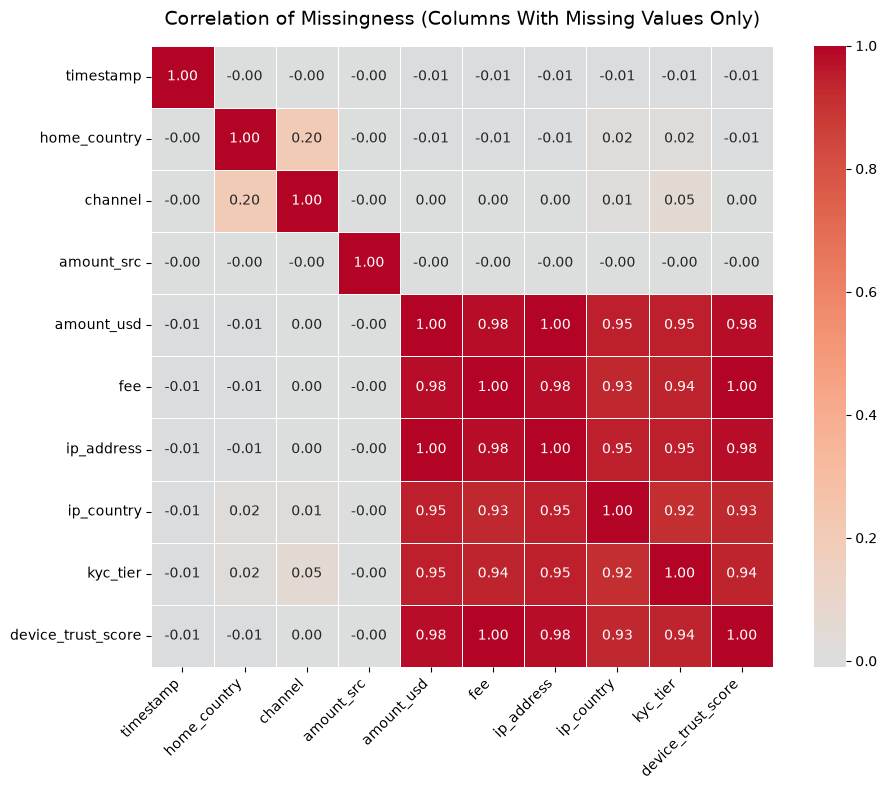

In [ ]:
# Checking for correlation of "is missing" across columns (1 = always missing together, 0 = unrelated)

missing_corr = df_transaction[missing_cols].isnull().corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(missing_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation of Missingness (Columns With Missing Values Only)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Beyond simply quantifying missing values, it was important to understand *why* they were missing — specifically, whether the missingness was random or systematically linked to fraudulent transactions or any other feature in the dataset. This distinction matters because non-random missingness can itself carry predictive signal, and handling it carelessly (e.g., blindly imputing or dropping rows) risks erasing that signal.

**Correlation of Missingness**

A correlation matrix was built on the "is-missing" indicator (`True`/`False`) for each column with missing values, to check whether columns tend to go missing together. The resulting heatmap revealed a clear pattern: `amount_usd`, `fee`, `ip_address`, `ip_country`, `kyc_tier`, and `device_trust_score` are strongly correlated with one another in their missingness, with correlation values ranging from approximately 0.92 to 1.00. This indicates that when one of these six fields is missing on a given transaction, the others are very likely missing as well — the gaps do not occur independently, but as a shared block.

In contrast, `timestamp` and `amount_src` showed near-zero correlation with this block and with each other, confirming their missingness is unrelated and can be treated independently.

In [ ]:
# Does this missingness relate to any other feature? 
# Channel

overlap_cols = ['amount_usd', 'fee', 'ip_address', 'ip_country', 'kyc_tier', 'device_trust_score']

df_transaction.groupby('channel')[overlap_cols].apply(lambda x: x.isnull().mean() * 100).round(1)

,amount_usd,fee,ip_address,ip_country,kyc_tier,device_trust_score
channel,,,,,,
atm,2.8,2.7,2.8,3.0,3.1,2.7
mobile,3.0,2.9,3.0,3.3,3.3,2.9
web,2.1,2.0,2.1,2.4,2.2,2.0


In [117]:
# Home_country

df_transaction.groupby('home_country')[overlap_cols].apply(lambda x: x.isnull().mean() * 100).round(1)

,amount_usd,fee,ip_address,ip_country,kyc_tier,device_trust_score
home_country,,,,,,
CA,1.9,1.8,1.9,2.1,1.9,1.8
UK,3.1,3.1,3.1,3.4,3.4,3.1
US,2.7,2.6,2.7,3.0,2.9,2.6


In [118]:
# Checking other possible feature

other_cols_to_check = ['source_currency', 'dest_currency', 'new_device', 'location_mismatch']

for col in other_cols_to_check:
    print(f"\n=== Missingness by {col} ===")
    print(df_transaction.groupby(col)[overlap_cols].apply(lambda x: x.isnull().mean() * 100).round(1))


=== Missingness by source_currency ===
                 amount_usd  fee  ...  kyc_tier  device_trust_score
source_currency                   ...                              
CAD                     1.9  1.8  ...       1.9                 1.8
GBP                     3.1  3.1  ...       3.5                 3.1
USD                     2.7  2.6  ...       3.0                 2.6

[3 rows x 6 columns]

=== Missingness by dest_currency ===
               amount_usd  fee  ...  kyc_tier  device_trust_score
dest_currency                   ...                              
CAD                   2.6  2.5  ...       2.9                 2.5
CNY                   2.3  2.2  ...       2.5                 2.2
EUR                   3.2  3.2  ...       3.7                 3.2
GBP                   3.1  3.0  ...       3.2                 3.0
INR                   2.7  2.6  ...       3.1                 2.6
MXN                   2.9  2.9  ...       3.1                 2.9
NGN                   2.9  2.8  

#### Searching for a Root Cause

Given that these six columns move together, the next step was to determine whether this pattern could be explained by any other feature in the dataset — that is, whether missingness was concentrated within a specific category (Missing At Random, conditional on an observed feature) rather than occurring at random overall.

The missingness rate for this block of six columns was compared across every relevant categorical feature available: `channel`, `home_country`, `source_currency`, `dest_currency`, and `new_device`. In each case, the missingness rate remained fairly consistent across all categories (typically ranging narrowly between 1.8% and 3.5%), with no category showing a disproportionately higher or lower rate. No feature in the dataset could account for why these six columns are missing together.

**Conclusion**

Since these six columns are missing together but this pattern could not be traced to any other feature or to fraud outcomes, the missingness cannot be classified as fully random or explained by a known cause — it is most likely driven by a shared upstream process (e.g., a single enrichment step that succeeds or fails as a unit).

As no explanatory driver was found, standard imputation will be used accordingly

#### Handling Missing Records

In [ ]:
# Timestamp - Drop all 61 rows will empty timestamp
df_transaction = df_transaction.dropna(subset=["timestamp"])

In [127]:
# amount_src - Dropp all 4 missing transaction amount
df_transaction = df_transaction.dropna(subset=["amount_src"])

In [ ]:
# IP Country - Fill 337 missing ip_country with corresponding source country currency country 

# Create a dictionary of currency - country 
currency_country_map = {"CAD": "CA", "GBP": "UK", "USD": "US"}

# Fill im missing IP country with currency_country_map
mapped_country = df_transaction["source_currency"].map(currency_country_map)
df_transaction["ip_country"] = df_transaction["ip_country"].fillna(mapped_country)

In [131]:
# Home Country - Fill in 32 missing home countries

# Step 1 - Check if home_country is always were customer transactions are made from

# Build a home_country_currency map
home_currency_map = currency_country_map

# Only check rows where home_country is known (not missing)
df_check = df_transaction.dropna(subset=['home_country']).copy()

# Apply the mapping to get the "expected" country based on source_currency
df_check['expected_home_country'] = df_check['source_currency'].map(home_currency_map)

# Compare expected vs actual
match_rate = (df_check['home_country'] == df_check['expected_home_country']).mean() * 100

print(f"Match rate: {match_rate:.2f}%")

Match rate: 100.00%


In [132]:
# Step 2 - Fill im missing Home country with home_currency_country_map
mapped_home_country = df_transaction["source_currency"].map(home_currency_map)
df_transaction["home_country"] = df_transaction["home_country"].fillna(mapped_home_country)

In [134]:
# Channel - Fill the 37 missing channels

df_transaction["channel"] = df_transaction["channel"].fillna(df_transaction["channel"].mode()[0])

In [136]:
# KYC Tier - Fill the 335 missing Know Your Customer Tier 

df_transaction["kyc_tier"] = df_transaction["kyc_tier"].fillna("not_captured")

In [ ]:
amount_usd                   305
fee                          295
ip_address                   305
device_trust_score           295